# Demo | Cap. 14: Regresión Lineal Simple
**Equipo:** loompy — Grus, Cap. 14

Ejemplos que corren sobre **Capital Federal** (`l2 = "Capital Federal"`). Comparamos varias columnas como variable x para ver cuál ajusta mejor el precio.

## Índice
1. Carga del dataset
2. Preparación de datos
3. Funciones del modelo
4. Comparación por R² (ranking)
5. Mejor variable: ajuste, predicciones y R²
6. Descenso del gradiente
7. Visualización


### Setup

    pip install -r requirements.txt


In [22]:
from pathlib import Path
import json
import urllib.request

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

#Para los gráficos:
plt.rcParams["figure.figsize"] = (8, 5)

COLOR_PRINCIPAL = "#a72424"
COLOR_SECUNDARIO = "#df6060"


## 1. Carga del dataset Properati

Leemos `entrenamiento.csv`.


In [23]:
# Carga el dataset Properati: primero busca el CSV local; si no está, lo baja de Kaggle.
def cargar_datos():
    # Opción 1: CSV local en data/ (un nivel arriba desde notebooks/)
    ruta_local = Path("../data/entrenamiento.csv")
    if ruta_local.exists():
        print("Archivo:", ruta_local)
        return pd.read_csv(ruta_local, low_memory=False)

    # Opción 2: si no está en local, descargar el dataset de Properati desde Kaggle
    import kagglehub
    carpeta = kagglehub.dataset_download("alejandroczernikier/properati-argentina-dataset")
    return pd.read_csv(Path(carpeta) / "entrenamiento.csv", low_memory=False)


datos_crudos = cargar_datos()
print("Filas totales:", len(datos_crudos))


Archivo: ..\data\entrenamiento.csv
Filas totales: 992192


## 2. Preparación de datos

- Solo **Capital Federal** (`l2 == "Capital Federal"`)
- Solo **departamentos en venta**
- Precio normalizado a **ARS** (API BCRA si está en USD)
- Guardamos varias columnas numéricas para probar después


In [24]:
URL_BCRA = "https://api.bcra.gob.ar/estadisticascambiarias/v1.0/Cotizaciones/USD"
CIUDAD = "Capital Federal"
PRECIO_MIN, PRECIO_MAX = 500_000, 80_000_000


# Consulta la API del BCRA y arma el tipo de cambio USD→ARS promedio por mes.
def cotizaciones_mensuales(desde, hasta):
    url = f"{URL_BCRA}?fechadesde={desde}&fechahasta={hasta}&limit=1000"
    req = urllib.request.Request(url, headers={"User-Agent": "loompy-lab1"})
    with urllib.request.urlopen(req, timeout=30) as resp:
        payload = json.loads(resp.read().decode())
    filas = [
        {"fecha": pd.to_datetime(i["fecha"]), "cotizacion": i["detalle"][0]["tipoCotizacion"]}
        for i in payload["results"]
    ]
    t = pd.DataFrame(filas).sort_values("fecha").set_index("fecha")["cotizacion"]
    mensual = t.resample("MS").mean()
    mensual.index = mensual.index.strftime("%Y-%m")
    return mensual


fechas = pd.to_datetime(datos_crudos["created_on"])
cotiz = cotizaciones_mensuales(fechas.min().strftime("%Y-%m-%d"), fechas.max().strftime("%Y-%m-%d"))
print("Cotizaciones USD→ARS (mensual):")
print(cotiz.round(2))
print()


# Devuelve la cotización del mes de una fecha (si falta, usa la última disponible).
def tc_mes(fecha):
    return float(cotiz.get(fecha.strftime("%Y-%m"), cotiz.iloc[-1]))


# Convierte el precio de una fila a ARS (deja ARS igual; multiplica USD por el TC del mes).
def precio_en_pesos(fila):
    if fila["currency"] == "ARS":
        return fila["price"]
    if fila["currency"] == "USD":
        return fila["price"] * tc_mes(fila["created_on"])
    return np.nan


datos = datos_crudos.copy()
datos["created_on"] = pd.to_datetime(datos["created_on"])

# Filtro geográfico: solo Capital Federal
datos = datos[datos["l2"] == CIUDAD]
print(f"Filas en {CIUDAD}:", len(datos))

datos = datos[
    (datos["property_type"] == "Departamento") & (datos["operation_type"] == "Venta")
]
print(f"Depto + venta:", len(datos))

datos = datos[datos["price"] > 0]
datos["precio_ars"] = datos.apply(precio_en_pesos, axis=1)
datos = datos.dropna(subset=["precio_ars"])
datos = datos[(datos["precio_ars"] >= PRECIO_MIN) & (datos["precio_ars"] <= PRECIO_MAX)]

print(f"\nFilas listas ({CIUDAD}, depto + venta + precio OK):", len(datos))


Cotizaciones USD→ARS (mensual):
fecha
2019-07    42.64
2019-08    52.59
2019-09    56.46
2019-10    58.54
2019-11    59.75
2019-12    59.88
2020-01    60.01
2020-02    61.36
2020-03    63.12
2020-04    65.76
2020-05    67.73
2020-06    69.54
2020-07    71.30
Name: cotizacion, dtype: float64

Filas en Capital Federal: 249738
Depto + venta: 105377

Filas listas (Capital Federal, depto + venta + precio OK): 99895


## 3. Funciones del modelo

Implementación desde cero (Grus, cap. 14).


In [25]:
# Predice y = pendiente * x + intercepto (recta de regresión).
def predecir(intercepto, pendiente, x):
    return pendiente * x + intercepto


# Suma de errores al cuadrado (SSE): mide qué tan lejos están las predicciones de y.
def suma_errores_cuadrado(intercepto, pendiente, x, y):
    return np.sum((predecir(intercepto, pendiente, x) - y) ** 2)


# Media aritmética de un vector.
def media(v):
    return np.mean(v)


# Desvío estándar de un vector.
def desviacion(v):
    return np.std(v)


# Correlación de Pearson entre x e y (qué tan linealmente se mueven juntas).
def correlacion(x, y):
    return np.corrcoef(x, y)[0, 1]


# Ajusta la recta por mínimos cuadrados y devuelve (intercepto alpha, pendiente beta).
def ajustar_minimos_cuadrados(x, y):
    beta = correlacion(x, y) * desviacion(y) / desviacion(x)
    alpha = media(y) - beta * media(x)
    return alpha, beta


# R²: proporción de la varianza de y explicada por la recta (1 = ajuste perfecto).
def r_cuadrado(intercepto, pendiente, x, y):
    sse = suma_errores_cuadrado(intercepto, pendiente, x, y)
    sst = np.sum((y - media(y)) ** 2)
    return 1 - sse / sst


print("Funciones listas.")


Funciones listas.


## 4. Comparación por R²

Probamos **precio_ars ~ columna** para varias variables y comparamos solo el **R²** (y la correlación).
En esta sección no armamos aún el ajuste completo: alcanza con rankear.


In [26]:
# columnas a probar: nombre técnico → (etiqueta legible, mínimo, máximo)
CANDIDATAS = {
    "surface_total": ("Superficie total (m²)", 20, 500),
    "surface_covered": ("Superficie cubierta (m²)", 20, 500),
    "rooms": ("Ambientes", 1, 10),
    "bedrooms": ("Dormitorios", 0, 8),
    "bathrooms": ("Baños", 1, 6),
}


# Filtra la columna, ajusta la recta y calcula solo métricas de ranking (sin guardar x/y).
def ranking_columna(base, columna, etiqueta, vmin, vmax):
    sub = base.dropna(subset=[columna, "precio_ars"]).copy()
    sub = sub[(sub[columna] >= vmin) & (sub[columna] <= vmax)]

    x = sub[columna].to_numpy(dtype=float)
    y = sub["precio_ars"].to_numpy(dtype=float)
    alpha, beta = ajustar_minimos_cuadrados(x, y)

    return {
        "columna": columna,
        "nombre": etiqueta,
        "filas": len(sub),
        "correlacion": correlacion(x, y),
        "r2": r_cuadrado(alpha, beta, x, y),
        "vmin": vmin,
        "vmax": vmax,
    }


ranking = [
    ranking_columna(datos, col, *params)
    for col, params in CANDIDATAS.items()
]

comparacion = pd.DataFrame([
    {
        "variable": r["nombre"],
        "columna": r["columna"],
        "filas": r["filas"],
        "correlacion": round(r["correlacion"], 4),
        "r2": round(r["r2"], 4),
    }
    for r in ranking
]).sort_values("r2", ascending=False).reset_index(drop=True)

print("Ranking por R² (de mayor a menor):")
comparacion


Ranking por R² (de mayor a menor):


,variable,columna,filas,correlacion,r2
0,Superficie cubierta (m²),surface_covered,76544,0.8142,0.6630
1,Superficie total (m²),surface_total,75305,0.7976,0.6362
2,Baños,bathrooms,95152,0.6888,0.4745
3,Ambientes,rooms,93550,0.5927,0.3513
4,Dormitorios,bedrooms,68646,0.5564,0.3095


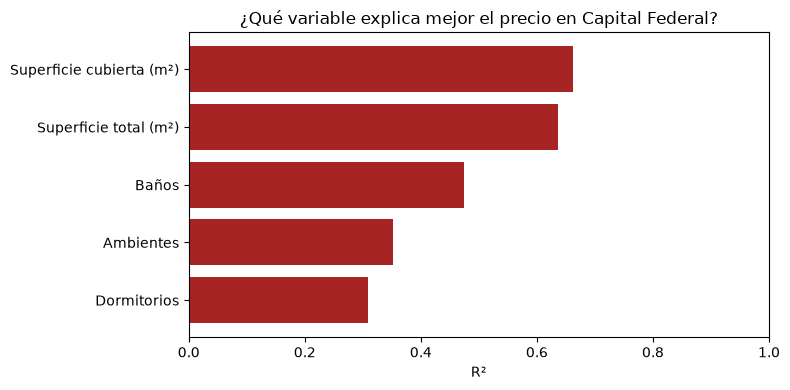

In [27]:
# Gráfico: R² por variable
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(comparacion["variable"], comparacion["r2"], color=COLOR_PRINCIPAL)
ax.set_xlabel("R²")
ax.set_title(f"¿Qué variable explica mejor el precio en {CIUDAD}?")
ax.set_xlim(0, 1)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


## 5. Mejor variable: ajuste, predicciones y R²

Elegimos la columna con mayor R² y **recién acá** armamos el dataset, el ajuste completo, predicciones de ejemplo y la interpretación del R².


In [28]:
# Mejor del ranking
mejor_rank = max(ranking, key=lambda r: r["r2"])
columna_x = mejor_rank["columna"]
nombre_x = mejor_rank["nombre"]
vmin, vmax = mejor_rank["vmin"], mejor_rank["vmax"]

# Dataset de la mejor variable (una sola vez)
sub = datos.dropna(subset=[columna_x, "precio_ars"]).copy()
sub = sub[(sub[columna_x] >= vmin) & (sub[columna_x] <= vmax)]
x = sub[columna_x].to_numpy(dtype=float)
y = sub["precio_ars"].to_numpy(dtype=float)

# Ajuste completo
alpha, beta = ajustar_minimos_cuadrados(x, y)
r2 = r_cuadrado(alpha, beta, x, y)

print(f"Mejor variable: {nombre_x} ({columna_x})")
print(f"Filas usadas: {len(sub):,}")
print(f"Correlación: {correlacion(x, y):.4f}")
print(f"R² = {r2:.4f}  →  explica el {r2 * 100:.1f}% de la variación del precio")
print(f"Intercepto α = {alpha:,.0f}")
print(f"Pendiente  β = {beta:,.0f}")
print(f"Modelo: precio_ars ≈ {beta:,.0f} × {columna_x} + ({alpha:,.0f})")


Mejor variable: Superficie cubierta (m²) (surface_covered)
Filas usadas: 76,544
Correlación: 0.8142
R² = 0.6630  →  explica el 66.3% de la variación del precio
Intercepto α = -782,202
Pendiente  β = 203,981
Modelo: precio_ars ≈ 203,981 × surface_covered + (-782,202)


## 6. Descenso del gradiente

Alternativa numérica: debería dar α y β similares a mínimos cuadrados.


OLS:       α=-782,202  β=203,981
Gradiente: α=-782,202  β=203,981


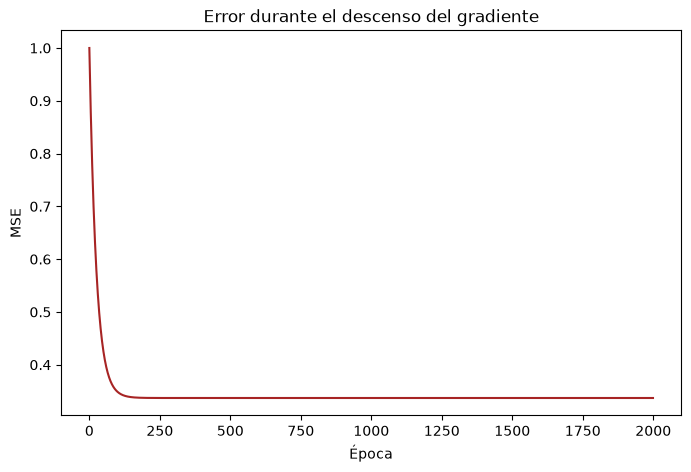

In [29]:
# Estandarizamos para que converja bien
x_mu, x_desv = media(x), desviacion(x)
y_mu, y_desv = media(y), desviacion(y)
x_n = (x - x_mu) / x_desv
y_n = (y - y_mu) / y_desv

a_g, b_g = 0.0, 0.0
tasa = 0.01
historial = []

for _ in range(2000):
    res = predecir(a_g, b_g, x_n) - y_n
    ga = 2 * np.sum(res) / len(x_n)
    gb = 2 * np.sum(res * x_n) / len(x_n)
    a_g -= tasa * ga
    b_g -= tasa * gb
    historial.append(np.mean(res ** 2))

alpha_gd = y_mu + y_desv * a_g - b_g * (y_desv / x_desv) * x_mu
beta_gd = b_g * (y_desv / x_desv)

print(f"OLS:       α={alpha:,.0f}  β={beta:,.0f}")
print(f"Gradiente: α={alpha_gd:,.0f}  β={beta_gd:,.0f}")

plt.plot(historial, color=COLOR_PRINCIPAL)
plt.title("Error durante el descenso del gradiente")
plt.xlabel("Época")
plt.ylabel("MSE")
plt.show()


## 7. Visualización: OLS vs gradiente descendente


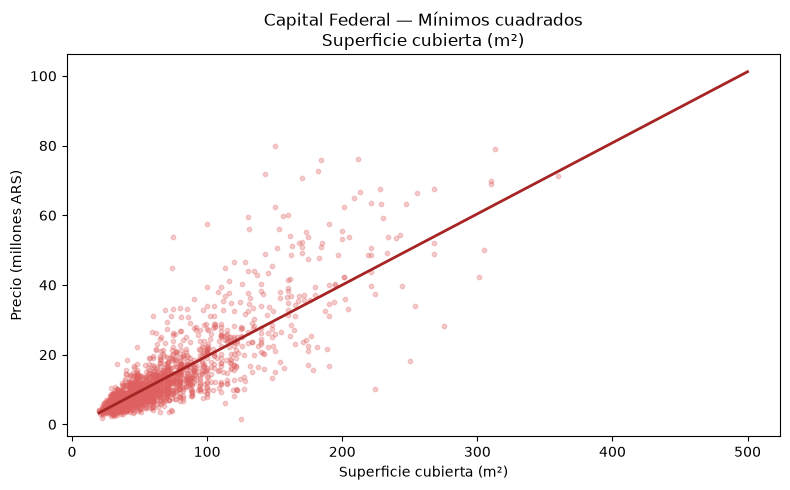

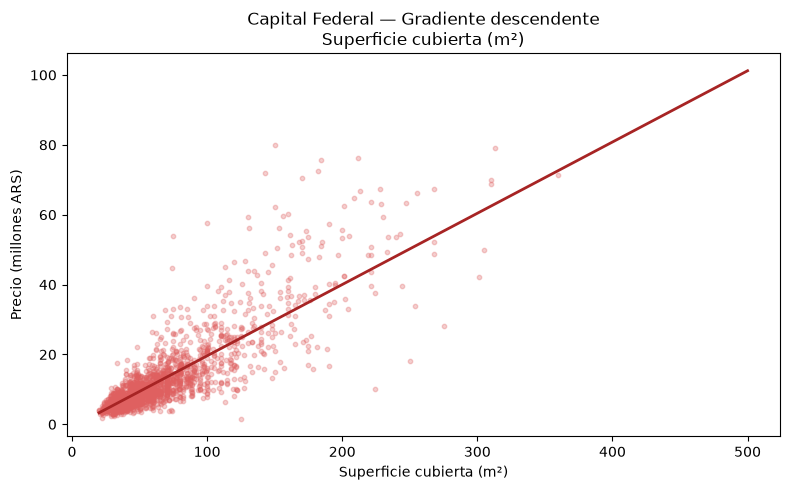

In [30]:
idx = np.random.default_rng(42).choice(len(x), size=min(2000, len(x)), replace=False)
xs, ys = x[idx], y[idx] / 1e6
x_line = np.linspace(x.min(), x.max(), 100)

for a, b, titulo in [
    (alpha, beta, "Mínimos cuadrados"),
    (alpha_gd, beta_gd, "Gradiente descendente"),
]:
    plt.figure()
    plt.scatter(xs, ys, alpha=0.3, s=10, color=COLOR_SECUNDARIO)
    plt.plot(x_line, predecir(a, b, x_line) / 1e6, color=COLOR_PRINCIPAL, linewidth=2)
    plt.title(f"{CIUDAD} — {titulo}\n{nombre_x}")
    plt.xlabel(nombre_x)
    plt.ylabel("Precio (millones ARS)")
    plt.tight_layout()
    plt.show()
